In [1]:
import os
import glob
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import ttest_rel

# --- Configuration ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif"
})

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Paths
EXPERIMENT = "lucas"
BASE_DIR = f"data/{EXPERIMENT}"
PACK_PATH = os.path.join(BASE_DIR, "lucas_pack.pkl")
RESULTS_DIR = os.path.join(BASE_DIR, "results_nonlinear")
EVAL_DIR = os.path.join(BASE_DIR, "evaluation_results")

# Ensure eval dir exists
os.makedirs(EVAL_DIR, exist_ok=True)

print(f"✅ Environment set up for {EXPERIMENT}")
print(f"📂 Results Directory: {RESULTS_DIR}")
print(f"📂 Evaluation CSVs Directory: {EVAL_DIR}")

✅ Environment set up for lucas
📂 Results Directory: data/lucas/results_nonlinear
📂 Evaluation CSVs Directory: data/lucas/evaluation_results


In [2]:
# 1. Load Data Pack (Needed for Omega Tests)
if os.path.exists(PACK_PATH):
    pack = joblib.load(PACK_PATH)
    OMEGA = pack["omega"] # True LL -> HL mapping
    # Extract raw samples for projection tests
    if "ll" in pack and "hl" in pack:
        Dll_samples = {k: pack["ll"][k]["X"] for k in pack["ll"]}
        Dhl_samples = {k: pack["hl"][k]["X"] for k in pack["hl"]}
    else:
        Dll_samples, Dhl_samples = {}, {}
    print(f"✅ Data Pack Loaded. Omega size: {len(OMEGA)}")
else:
    print("⚠️ Pack not found. Omega tests will fail.")
    OMEGA = {}
    Dll_samples, Dhl_samples = {}, {}

# 2. Label Maps
LABEL_MAP_RAW = {
    'DiRoCA (eps_0.5_delta_0.5)': 'DiRoCA_0.5',
    'DiRoCA (eps_1.0_delta_1.0)': 'DiRoCA_1',
    'DiRoCA (eps_2.0_delta_2.0)': 'DiRoCA_2',
    'DiRoCA (eps_4.0_delta_4.0)': 'DiRoCA_4',
    'DiRoCA (eps_8.0_delta_8.0)': 'DiRoCA_8',
    'diroca': 'DiRoCA_1',
    'gradca': 'GradCA',
    'GradCA': 'GradCA',
    'baryca': 'BARYCA',
    'BaryCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)': 'Abslin_n'
}

PRINT_LABEL_MAP = {
    "DiRoCA_0.5": r"DiRoCA$_{0.5}$",
    "DiRoCA_1"  : r"DiRoCA$_{1.0}$",
    "DiRoCA_2"  : r"DiRoCA$_{2.0}$",
    "DiRoCA_4"  : r"DiRoCA$_{4.0}$",
    "DiRoCA_8"  : r"DiRoCA$_{8.0}$",
    "GradCA"    : r"GRAD$_{(\tau, \omega)}$",
    "BARYCA"    : r"BARY$_{(\tau, \omega)}$",
    "Abslin_p"  : r"AbsLin$_{\text{p}}$",
    "Abslin_n"  : r"AbsLin$_{\text{n}}$"
}

# 3. Colors
display_names = list(PRINT_LABEL_MAP.values())
palette_colors = sns.color_palette("colorblind", n_colors=len(display_names))
COLOR_MAP = dict(zip(display_names, palette_colors))

# 4. Helper: Load CSVs
def load_lucas_results(distribution, shift="additive"):
    # Look for ALL files matching the pattern
    pattern = f"empirical_evaluation_{shift}_{distribution}_*.csv"
    search_path = os.path.join(EVAL_DIR, pattern)
    files = sorted(glob.glob(search_path))
    
    if not files:
        print(f"❌ No files found for {distribution} (Pattern: {pattern})")
        return None
    
    print(f"Combine {len(files)} files for [{distribution}]:")
    dfs = []
    for f in files:
        try:
            tmp_df = pd.read_csv(f)
            dfs.append(tmp_df)
            print(f"  - Loaded {os.path.basename(f)} ({len(tmp_df)} rows)")
        except Exception as e:
            print(f"  ⚠️ Error loading {os.path.basename(f)}: {e}")

    if not dfs:
        return None

    # Concatenate all runs
    df = pd.concat(dfs, ignore_index=True)
    
    # Standardize Method Names
    df['method'] = df['method'].astype(str).map(lambda x: LABEL_MAP_RAW.get(x, x))
    
    # Optional: Deduplicate
    initial_len = len(df)
    subset_cols = ['method', 'alpha', 'noise_scale', 'trial', 'fold'] # Updated col names to match script
    
    # Check column existence before dedup (noise_std vs noise_scale)
    if 'noise_scale' in df.columns:
        dedup_cols = [c for c in subset_cols if c in df.columns]
        df = df.drop_duplicates(subset=dedup_cols, keep='last')
    
    print(f"✅ Total rows after merge: {len(df)} (Dropped {initial_len - len(df)} duplicates)")
    
    return df

✅ Data Pack Loaded. Omega size: 11


In [3]:
def get_closest_sigma(df, target):
    """Finds available sigma in df closest to target."""
    # Handle noise column name variations
    col = 'noise_scale' if 'noise_scale' in df.columns else 'noise_std'
    if col not in df.columns: return target
        
    available = df[col].unique()
    return available[np.argmin(np.abs(available - target))]

def run_plots(df, methods, target_sigma=10.0, target_alpha=1.0):
    """
    Generates 2 plots: 
    1. Error vs Alpha (fixed Sigma)
    2. Error vs Sigma (fixed Alpha)
    """
    # Filter methods
    df = df[df['method'].isin(methods)].copy()
    df['display_name'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
    
    # Determine noise column name
    noise_col = 'noise_scale' if 'noise_scale' in df.columns else 'noise_std'
    
    # Common Order
    hue_order = sorted(df['display_name'].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Plot 1: Vary Alpha (Fix Sigma) ---
    real_sigma = get_closest_sigma(df, target_sigma)
    df_sig = df[np.isclose(df[noise_col], real_sigma)]
    
    sns.lineplot(
        data=df_sig, x='alpha', y='error', hue='display_name',
        hue_order=hue_order, palette=COLOR_MAP, marker='o', errorbar='sd', ax=axes[0]
    )
    axes[0].set_title(f"Abstraction Error vs. Alpha ($\\tilde{{\\sigma}} \\approx {real_sigma}$)")
    axes[0].set_ylabel("Error (Frobenius)")
    axes[0].grid(True, alpha=0.5, linestyle='--')
    
    # --- Plot 2: Vary Sigma (Fix Alpha) ---
    df_alp = df[np.isclose(df['alpha'], target_alpha)]
    
    sns.lineplot(
        data=df_alp, x=noise_col, y='error', hue='display_name',
        hue_order=hue_order, palette=COLOR_MAP, marker='o', errorbar='sd', ax=axes[1]
    )
    axes[1].set_title(f"Abstraction Error vs. Noise ($\\alpha = {target_alpha}$)")
    axes[1].set_xlabel("Noise Scale ($\\tilde{{\\sigma}}$)")
    axes[1].grid(True, alpha=0.5, linestyle='--')
    
    plt.tight_layout()
    plt.show()

In [4]:
def generate_stats_table(df, methods_of_interest, alpha_vals=[0.0, 1.0], target_sigma=10.0):
    """
    Generates summary table with Paired T-Tests against the best method.
    """
    noise_col = 'noise_scale' if 'noise_scale' in df.columns else 'noise_std'
    real_sigma = get_closest_sigma(df, target_sigma)
    print(f"\n📊 Huber Stats (Sigma ≈ {real_sigma:.2f})")
    
    results = []
    df_sig = df[np.isclose(df[noise_col], real_sigma)].copy()
    
    for alpha in alpha_vals:
        df_alpha = df_sig[np.isclose(df_sig['alpha'], alpha)].copy()
        
        # Pivot for paired testing: Index by fold/trial/seed
        pivot_cols = [c for c in ['fold', 'trial', 'seed'] if c in df_alpha.columns]
        if not pivot_cols:
            continue
            
        paired_df = df_alpha.pivot_table(index=pivot_cols, columns='method', values='error')
        valid_methods = [m for m in methods_of_interest if m in paired_df.columns]
        
        if not valid_methods: continue

        # Identify Winner
        mean_scores = paired_df[valid_methods].mean()
        best_method = mean_scores.idxmin()
        best_disp = PRINT_LABEL_MAP.get(best_method, best_method)
        ref_scores = paired_df[best_method]

        for method in valid_methods:
            scores = paired_df[method]
            mean_err = scores.mean()
            std_err = scores.std()
            
            sig_str = ""
            if method == best_method:
                sig_str = "--- (Ref)"
            else:
                # Paired T-Test
                common = ref_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p_val = ttest_rel(ref_scores.loc[common], scores.loc[common])
                    if p_val < 0.001: sig_str = "***"
                    elif p_val < 0.01: sig_str = "**"
                    elif p_val < 0.05: sig_str = "*"

            results.append({
                "Condition": f"α={alpha}",
                "Method": PRINT_LABEL_MAP.get(method, method),
                "Mean Error": mean_err,
                "Std": std_err,
                "Sig.": sig_str
            })

    res_df = pd.DataFrame(results)
    
    # Print formatted
    for alpha in alpha_vals:
        print(f"\n--- Alpha = {alpha} ---")
        sub = res_df[res_df['Condition'] == f"α={alpha}"].sort_values("Mean Error")
        print(sub.drop(columns=['Condition']).to_string(index=False, float_format="%.4f"))
        
    return res_df

In [5]:
def run_omega_misspecification(omega_map, results_dir, dll, dhl, num_trials=10):
    """
    Loads saved T-matrices and re-evaluates them using a corrupted Omega map.
    Returns a DataFrame suitable for the stats function.
    """
    # 1. Load Saved Folds from DiRoCA results (assuming it exists to get fold indices)
    ref_pkl = os.path.join(results_dir, "diroca_cv_results_empirical.pkl")
    if not os.path.exists(ref_pkl): 
        # Try finding ANY result file to get indices
        pkls = glob.glob(os.path.join(results_dir, "*.pkl"))
        if pkls: ref_pkl = pkls[0]
        else: return pd.DataFrame()
    
    loaded_ref = joblib.load(ref_pkl)
    saved_folds = []
    # Extract test indices per fold
    for k, v in loaded_ref.items():
        if "fold_" in k:
            # v is dict of runs, take first one to get indices
            # Handle standard vs nested structure
            first_run_key = next(iter(v.keys()))
            first_run = v[first_run_key]
            if "test_indices" in first_run:
                saved_folds.append({"id": int(k.split("_")[1]), "test": first_run["test_indices"]})

    # 2. Load all method PKLs
    pkl_files = glob.glob(os.path.join(results_dir, "*_cv_results_empirical.pkl"))
    records = []
    
    # We test MAXIMAL corruption (swapping everything possible)
    K_corruption = len(omega_map) 
    
    print(f"🔄 Running Omega Test (K={K_corruption} swaps) on {len(pkl_files)} files...")

    for trial in tqdm(range(num_trials)):
        # -- Generate Corrupt Map --
        corrupt_omega = omega_map.copy()
        ll_keys = list(omega_map.keys())
        # Simple random shuffle logic ensuring semantic mismatch
        hl_targets = list(omega_map.values())
        
        # For maximal corruption: simple derangement or random shuffle
        random.shuffle(ll_keys)
        for i, ll_node in enumerate(ll_keys):
            # Assign random target from HL list (simulating bad alignment)
            target = random.choice(hl_targets)
            corrupt_omega[ll_node] = target

        # -- Evaluate --
        for pkl_path in pkl_files:
            base_name = os.path.basename(pkl_path).replace("_cv_results_empirical.pkl", "")
            data = joblib.load(pkl_path)
            
            for fold in saved_folds:
                fold_key = f"fold_{fold['id']}"
                if fold_key not in data: continue
                
                runs = data[fold_key]
                test_idx = fold["test"]
                
                for run_id, res in runs.items():
                    # Get T
                    T = res.get("T_matrix", res.get("T"))
                    if T is None: continue
                    
                    # Project and Compute Error based on CORRUPT Omega
                    errors = []
                    for ll_node, _ in omega_map.items():
                        # We THINK ll_node maps to corrupt_omega[ll_node]
                        if ll_node not in corrupt_omega: continue
                        target_hl = corrupt_omega[ll_node]
                        
                        if ll_node not in dll or target_hl not in dhl: continue

                        X_ll = dll[ll_node][test_idx]
                        X_hl = dhl[target_hl][test_idx] # The "Wrong" target
                        
                        # Apply T projection
                        X_pred = X_ll @ T.T
                        err = np.linalg.norm(X_pred - X_hl, ord='fro') / np.sqrt(len(test_idx))
                        errors.append(err)
                    
                    if not errors: continue

                    # Store
                    clean_name = base_name
                    # Normalize names to match LABEL_MAP
                    if "diroca" in base_name: clean_name = f"DiRoCA_{run_id}" 
                    elif "abslin" in base_name: clean_name = f"Abslin_{run_id}"

                    if "eps_" in clean_name:
                        if "eps_0.5" in clean_name: clean_name = "DiRoCA_0.5"
                        elif "eps_1.0" in clean_name: clean_name = "DiRoCA_1"
                        elif "eps_2.0" in clean_name: clean_name = "DiRoCA_2"
                        elif "eps_4.0" in clean_name: clean_name = "DiRoCA_4"
                        elif "eps_8.0" in clean_name: clean_name = "DiRoCA_8"
                    
                    if "Perfect" in str(run_id): clean_name = "Abslin_p"
                    if "Noisy" in str(run_id): clean_name = "Abslin_n"
                    if "gradca" in base_name: clean_name = "GradCA"
                    if "baryca" in base_name: clean_name = "BARYCA"

                    records.append({
                        "method": clean_name,
                        "fold": fold['id'],
                        "trial": trial,
                        "error": np.mean(errors)
                    })
                    
    return pd.DataFrame(records)

def generate_omega_stats(df):
    """
    Same statistical logic as Huber, but for Omega Robustness.
    """
    if df.empty: return
    
    print("\n📊 Omega Misspecification Stats (Maximal Corruption)")
    
    pivot_cols = ['fold', 'trial']
    paired_df = df.pivot_table(index=pivot_cols, columns='method', values='error')
    
    if paired_df.empty:
        print("No valid paired data found.")
        return

    mean_scores = paired_df.mean()
    best_method = mean_scores.idxmin() # Lowest error = Most Robust
    best_disp = PRINT_LABEL_MAP.get(best_method, best_method)
    
    print(f"  > Most Robust Method: {best_disp} (Error={mean_scores[best_method]:.2f})")
    
    results = []
    ref_scores = paired_df[best_method]
    
    for method in paired_df.columns:
        scores = paired_df[method]
        sig_str = ""
        
        if method == best_method:
            sig_str = "--- (Ref)"
        else:
            common = ref_scores.dropna().index.intersection(scores.dropna().index)
            if len(common) > 1:
                _, p_val = ttest_rel(ref_scores.loc[common], scores.loc[common])
                if p_val < 0.001: sig_str = "***"
                elif p_val < 0.01: sig_str = "**"
                elif p_val < 0.05: sig_str = "*"
        
        results.append({
            "Method": PRINT_LABEL_MAP.get(method, method),
            "Mean Error": scores.mean(),
            "Std": scores.std(),
            "Sig.": sig_str
        })
        
    out_df = pd.DataFrame(results).sort_values("Mean Error")
    print(out_df.to_string(index=False, float_format="%.4f"))

Combine 1 files for [gaussian]:
  - Loaded empirical_evaluation_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_zero_meanTrue_kfolds5_seed23_20251209_163640.csv (180000 rows)
✅ Total rows after merge: 180000 (Dropped 0 duplicates)


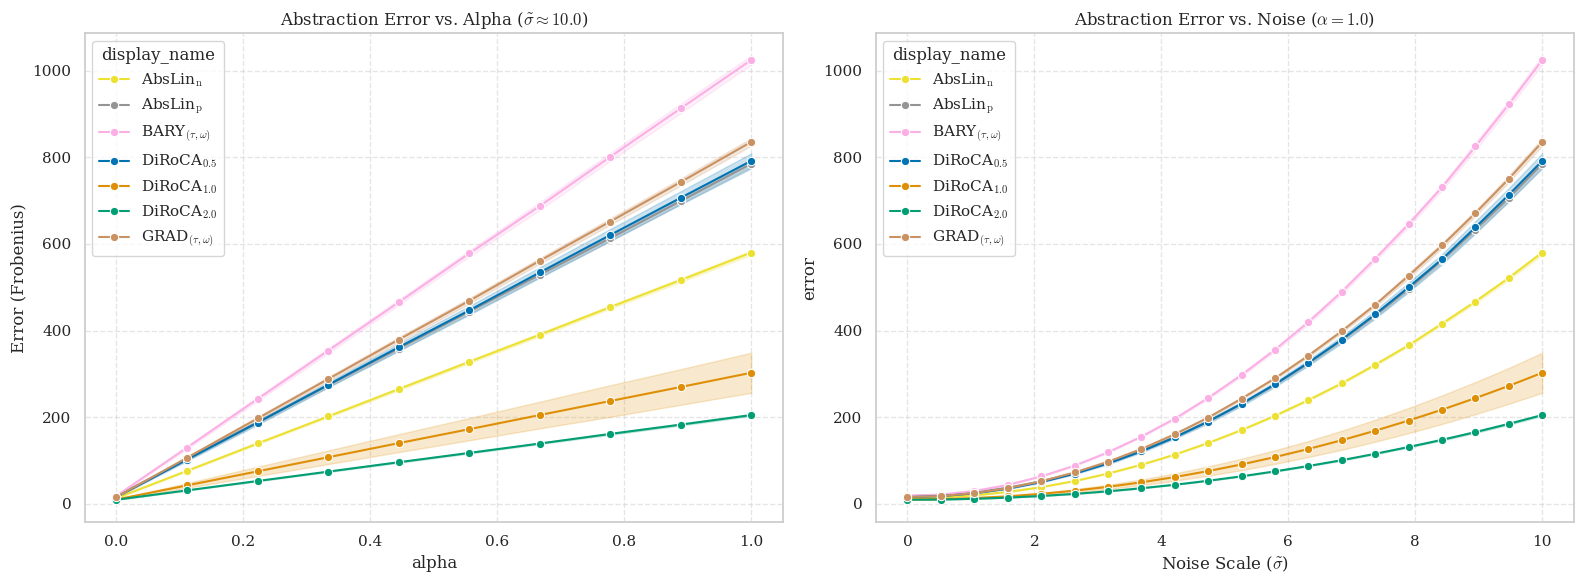


📊 Huber Stats (Sigma ≈ 10.00)

--- Alpha = 0.0 ---
                 Method  Mean Error    Std      Sig.
         DiRoCA$_{2.0}$      9.6665 0.1107 --- (Ref)
         DiRoCA$_{1.0}$     10.2707 0.5312       ***
    AbsLin$_{\text{n}}$     13.4886 0.4393       ***
         DiRoCA$_{0.5}$     15.8261 0.2352       ***
GRAD$_{(\tau, \omega)}$     15.8839 0.1278       ***
    AbsLin$_{\text{p}}$     18.2915 0.1592       ***
BARY$_{(\tau, \omega)}$     18.7384 0.1091       ***

--- Alpha = 1.0 ---
                 Method  Mean Error     Std      Sig.
         DiRoCA$_{2.0}$    205.0921  2.0911 --- (Ref)
         DiRoCA$_{1.0}$    302.7283 46.2893       ***
    AbsLin$_{\text{n}}$    580.0641  5.0912       ***
    AbsLin$_{\text{p}}$    785.2379  8.0131       ***
         DiRoCA$_{0.5}$    791.8040 17.3599       ***
GRAD$_{(\tau, \omega)}$    835.4501  8.5284       ***
BARY$_{(\tau, \omega)}$   1024.5429 10.2529       ***
🔄 Running Omega Test (K=11 swaps) on 4 files...


  0%|          | 0/20 [00:00<?, ?it/s]


📊 Omega Misspecification Stats (Maximal Corruption)
  > Most Robust Method: DiRoCA$_{2.0}$ (Error=5.28)
                 Method  Mean Error    Std      Sig.
         DiRoCA$_{2.0}$      5.2833 0.3349 --- (Ref)
         DiRoCA$_{1.0}$      5.6977 0.3437       ***
    AbsLin$_{\text{n}}$      6.6597 0.2660       ***
         DiRoCA$_{0.5}$      7.2812 0.2302       ***
GRAD$_{(\tau, \omega)}$      7.3041 0.2298       ***
    AbsLin$_{\text{p}}$      7.9003 0.2066       ***
BARY$_{(\tau, \omega)}$      7.9560 0.2098       ***


In [8]:
# --- 1. Settings ---
DISTRIBUTION = 'gaussian' # 'gaussian', 'student-t', 'exponential'
METHODS_TO_ANALYZE = [
    'DiRoCA_0.5', 'DiRoCA_1', 'DiRoCA_2', 
    'GradCA', 'BARYCA', 'Abslin_p', 'Abslin_n'
]

# --- 2. Load Results ---
df_res = load_lucas_results(DISTRIBUTION)

if df_res is not None:
    # --- 3. Run Plots ---
    # target_sigma=10.0 is the max noise in standard Lucas setup (adjust if you ran up to 5)
    run_plots(df_res, METHODS_TO_ANALYZE, target_sigma=10.0, target_alpha=1.0)
    
    # --- 4. Huber Stats Table ---
    generate_stats_table(df_res, METHODS_TO_ANALYZE, alpha_vals=[0.0, 1.0], target_sigma=10.0)

# --- 5. Omega Misspecification Analysis ---
if os.path.exists(PACK_PATH):
    omega_df = run_omega_misspecification(
        OMEGA, 
        RESULTS_DIR, 
        Dll_samples, 
        Dhl_samples, 
        num_trials=20
    )
    
    # Filter for methods of interest
    if not omega_df.empty:
        omega_df_filtered = omega_df[omega_df['method'].isin(METHODS_TO_ANALYZE)]
        generate_omega_stats(omega_df_filtered)